# Gini


In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import pandas as pd

from urban_mobility import fetch_data as fd
from urban_mobility import plotting as pl
from urban_mobility.metrics import calc_gini, gini_by_state, lorenz_points
from urban_mobility.utils import cached_df

fd.fetch_traffic_data()

Already have 2016.csv, skipping...
Already have 2017.csv, skipping...
Already have 2018.csv, skipping...
Already have 2019.csv, skipping...
Already have 2020.csv, skipping...
Already have 2021.csv, skipping...
Already have 2022.csv, skipping...
Already have 2023.csv, skipping...
Already have 2024.csv, skipping...
Already have 2025.csv, skipping...


In [2]:
YEARS = fd.DATA_YEARS
LATEST = YEARS[-1]

## Data Cleaning


Aggregate the accidents and join them with the city info (`fd.get_city_aggregate`): it one-hot encodes the injury severity, groups by the columns given, joins on `"regional key"` and adds the total injuries. The result is cached under `output/artifacts`.


In [ ]:
agg_methods = {
    "inj_light": "sum",
    "inj_serious": "sum",
    "inj_fatal": "sum",
    "IstFuss": "sum",
    "IstRad": "sum",
    "IstKrad": "sum",
    "IstGkfz": "sum",
    "ULAND": "first",
}

df_merged = fd.get_city_aggregate(YEARS, ["Community_key", "UJAHR"], agg_methods)

In [4]:
# Sanity check
df_merged[df_merged["UJAHR"] == LATEST].head()

,regional key,UJAHR,inj_light,inj_serious,inj_fatal,IstFuss,IstRad,IstKrad,IstGkfz,ULAND,city,sq km,population,inj_total
9,01001000,2025,347,26,1,42,186,21,7.0,01,Flensburg,56.73,96326,374
19,01002000,2025,872,86,5,110,464,74,31.0,01,Kiel,118.65,252668,963
29,01003000,2025,1071,99,1,97,644,92,21.0,01,Lübeck,214.19,216889,1171
39,01004000,2025,307,45,0,32,127,30,11.0,01,Neumünster,71.66,79809,352
49,01051011,2025,35,2,1,1,16,4,0.0,01,Brunsbüttel,65.21,12692,38


## Gini

We calculate the gini-index. Normally, the gini-index is used as a measure for wealth disparity. Here, we seek to use it as a metric to inform about the relative share of fatalities between cities. In this context, a gini-index of 0 would mean that fatalities are equally distributed between cities while a gini-index of 1 would mean that the fatalities are are concentrated in one city. On our dataset it is possible to obtain a negative gini-index. This can be interpreted as lower-population cities contributing more to the category than their higher-population counterparts. If all one cares about is to quantify the disparity disregarding the direction, one can take the absolute value of the gini-index so it is in the range `[0, 1]`.


In [5]:
pop_label = "population"

In [6]:
def plot_lorenz_curve(
    df: pd.DataFrame, year: int, val_label: str, val_title: str, ax=None
):
    """Lorenz curve of ``val_label`` against population, ordered by population."""
    x, y = lorenz_points(df, pop_label, val_label)
    gini = calc_gini(df, pop_label, val_label)
    return pl.lorenz(x, y, gini, f"{val_title} ({year})", val_title, ax=ax)

Plot the Lorenz Curve for certain categories and types.


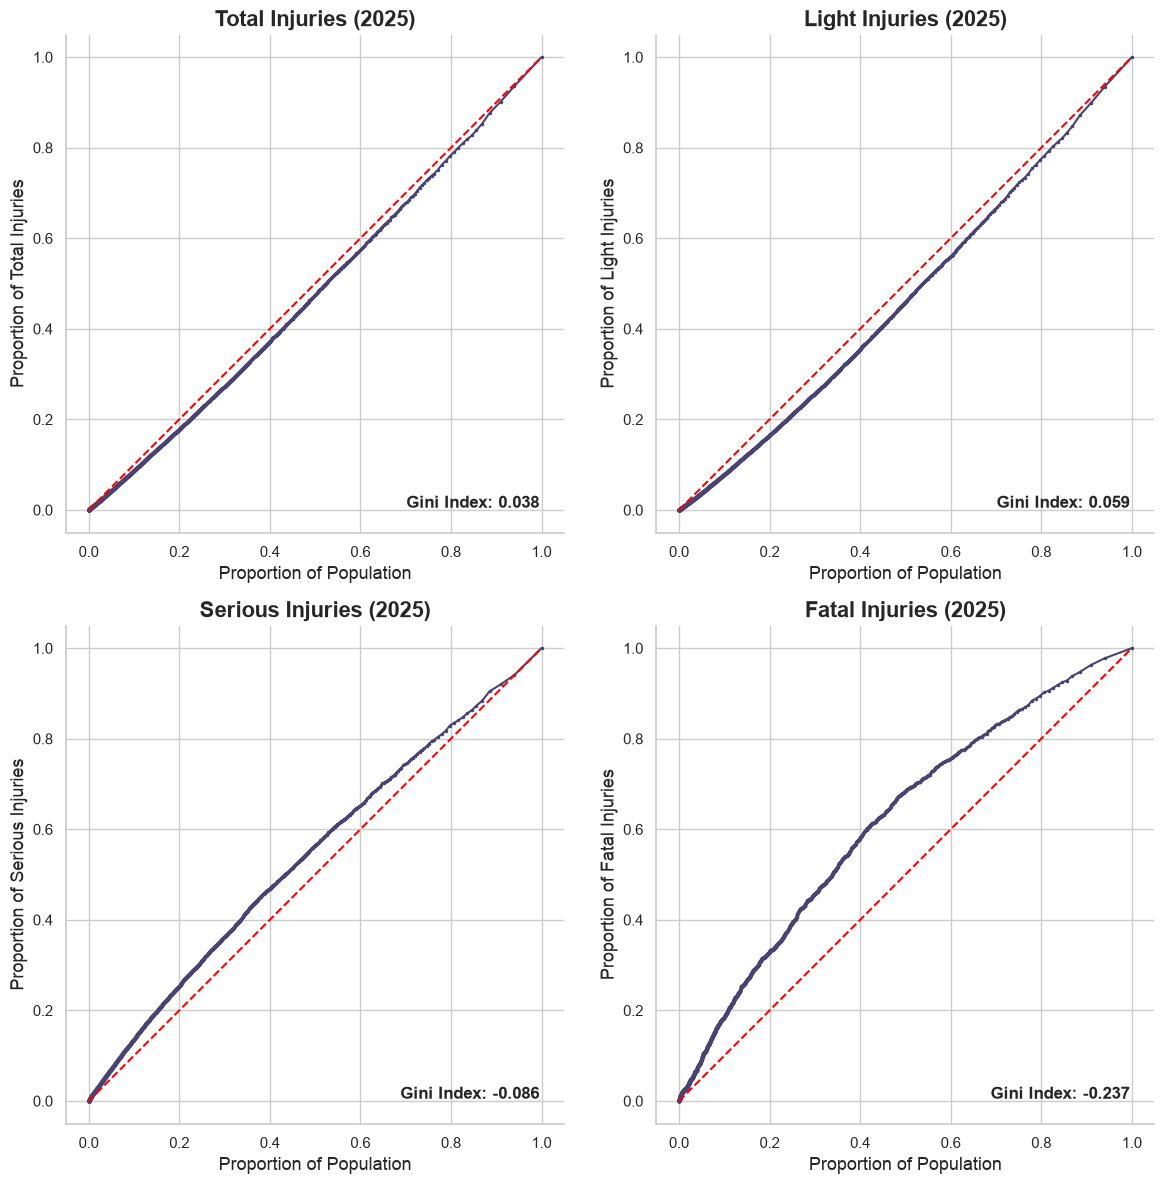

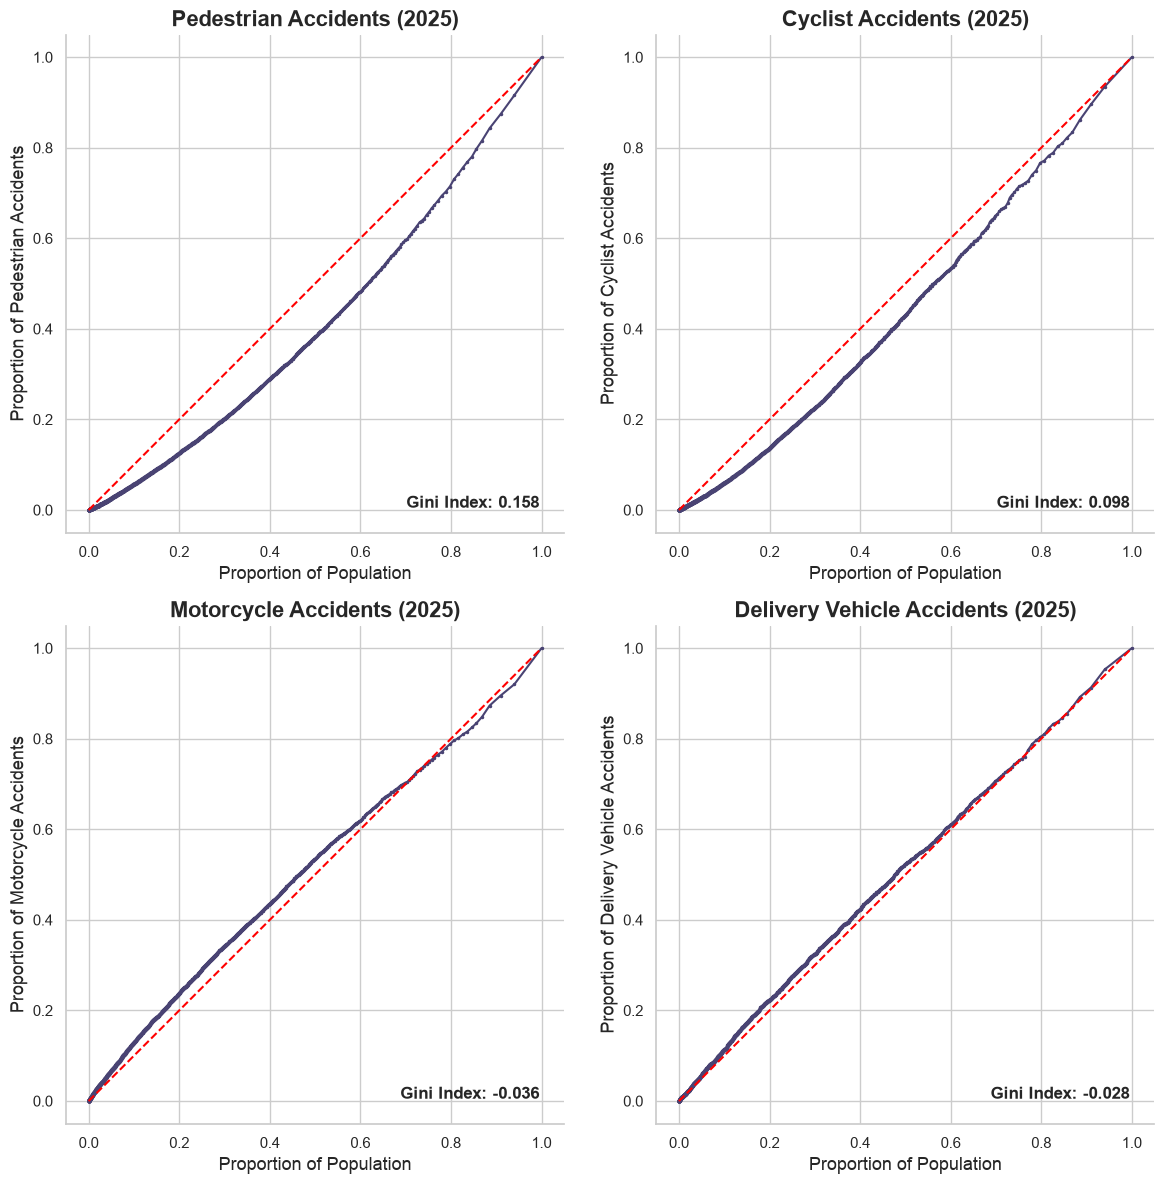

In [7]:
df_yr = df_merged[df_merged["UJAHR"] == LATEST]

for group, measures in pl.MEASURE_GROUPS.items():
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    for ax, (col, label) in zip(axes.flat, measures):
        plot_lorenz_curve(df_yr, LATEST, col, label, ax=ax)
    fig.tight_layout()
    pl.save(fig, f"gini_{group}")
    plt.show()

### Gini of Germany
Not every state reports from 2016 (all 16 only from 2020, see `metrics.STATES`), so the Germany-wide index before 2020 covers fewer states.

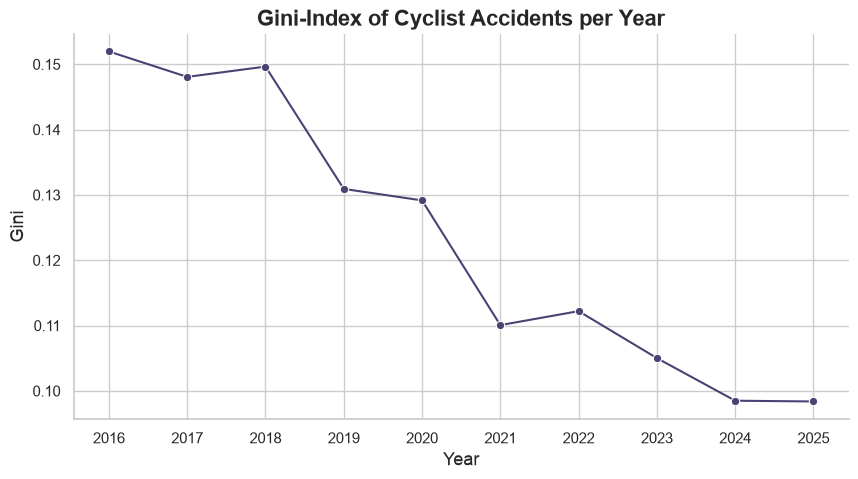

In [8]:
col = "IstRad"


def gini_by_year() -> pd.DataFrame:
    ginis = [
        calc_gini(
            df_merged[df_merged["UJAHR"] == year][["city", pop_label, col]],
            pop_label,
            col,
        )
        for year in YEARS
    ]
    return pd.DataFrame({"Year": YEARS, "Gini": ginis})


df_year = cached_df(f"gini/by_year_{col}_{YEARS[0]}-{YEARS[-1]}", gini_by_year)
ax = pl.line_chart(
    df_year,
    "Year",
    "Gini",
    f"Gini-Index of {pl.MEASURE_LABELS[col]} per Year",
)
pl.save(ax.figure, f"gini_index_{col.lower()}_de")
plt.show()

### Gini per State
Berlin and Hamburg are a single city each and Bremen has two, so their Gini index across cities is 0 or close to it by construction. `gini_by_state` leaves out states with fewer than 3 cities.

In [9]:
df_gini = cached_df(
    f"gini/by_state_{col}_{YEARS[0]}-{YEARS[-1]}", lambda: gini_by_state(df_merged, col)
)

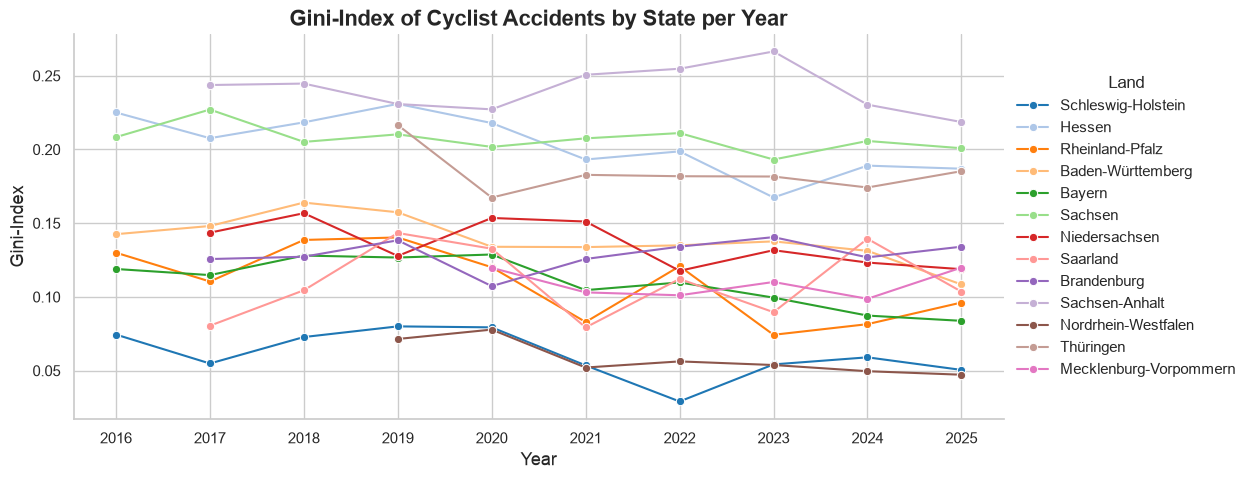

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
pl.line_chart(
    df_gini,
    "Year",
    "Gini",
    f"Gini-Index of {pl.MEASURE_LABELS[col]} by State per Year",
    ylabel="Gini-Index",
    hue="Land",
    ax=ax,
)
pl.save(fig, f"gini_index_{col.lower()}_land")
plt.show()